### Project Objective

##### This project explores key macroeconomic indicators of the United States using data from the Federal Reserve Economic Data (FRED) database.
 
##### The goal is to analyze how major economic variables such as GDP, unemployment, inflation, interest rates, and the stock market interact during different phases of the economic cycle, especially during the COVID-19 recession and the recovery period that followed.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from fredapi import Fred
from dotenv import load_dotenv
import os

load_dotenv()

fred = Fred(api_key=os.getenv("FRED_API_KEY"))

plt.style.use("fivethirtyeight")
pd.set_option('display.max_columns', 500)
pd.set_option("display.float_format", "{:.2f}".format)
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]

In [226]:
START_DATE = "2017"
END_DATE = "2026"

## Economic Data From The Federal Reserve Economic Database (FRED)

### Search all Datasets related to S&P

In [227]:
sp_search = fred.search("S&P")
sp_search.head()

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
SP500,SP500,2026-03-08,2026-03-08,S&P 500,2016-03-07,2026-03-06,"Daily, Close",D,Index,Index,Not Seasonally Adjusted,NSA,2026-03-06 19:01:50-06:00,91,The observations for the S&P 500 represent the...
CSUSHPINSA,CSUSHPINSA,2026-03-08,2026-03-08,S&P Cotality Case-Shiller U.S. National Home P...,1987-01-01,2025-12-01,Monthly,M,Index Jan 2000=100,Index Jan 2000=100,Not Seasonally Adjusted,NSA,2026-02-24 08:15:26-06:00,85,"For more information regarding the index, plea..."
CSUSHPISA,CSUSHPISA,2026-03-08,2026-03-08,S&P Cotality Case-Shiller U.S. National Home P...,1987-01-01,2025-12-01,Monthly,M,Index Jan 2000=100,Index Jan 2000=100,Seasonally Adjusted,SA,2026-02-24 08:15:04-06:00,73,"For more information regarding the index, plea..."
SPCS20RSA,SPCS20RSA,2026-03-08,2026-03-08,S&P Cotality Case-Shiller 20-City Composite Ho...,2000-01-01,2025-12-01,Monthly,M,Index Jan 2000=100,Index Jan 2000=100,Seasonally Adjusted,SA,2026-02-24 08:14:08-06:00,60,"For more information regarding the index, plea..."
SPCS20RNSA,SPCS20RNSA,2026-03-08,2026-03-08,S&P Cotality Case-Shiller 20-City Composite Ho...,2000-01-01,2025-12-01,Monthly,M,Index Jan 2000=100,Index Jan 2000=100,Not Seasonally Adjusted,NSA,2026-02-24 08:13:55-06:00,29,"For more information regarding the index, plea..."


### Ordering all Datasets Related to S&P By Popularity

In [228]:
sp_search = fred.search('S&P' , order_by='popularity')
sp_search.head(5)

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
BAMLH0A0HYM2,BAMLH0A0HYM2,2026-03-08,2026-03-08,ICE BofA US High Yield Index Option-Adjusted S...,1996-12-31,2026-03-05,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 08:43:46-06:00,100,The ICE BofA Option-Adjusted Spreads (OASs) ar...
SP500,SP500,2026-03-08,2026-03-08,S&P 500,2016-03-07,2026-03-06,"Daily, Close",D,Index,Index,Not Seasonally Adjusted,NSA,2026-03-06 19:01:50-06:00,91,The observations for the S&P 500 represent the...
BAMLC0A0CM,BAMLC0A0CM,2026-03-08,2026-03-08,ICE BofA US Corporate Index Option-Adjusted Sp...,1996-12-31,2026-03-05,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 08:44:52-06:00,86,The ICE BofA Option-Adjusted Spreads (OASs) ar...
BAMLH0A0HYM2EY,BAMLH0A0HYM2EY,2026-03-08,2026-03-08,ICE BofA US High Yield Index Effective Yield,1996-12-31,2026-03-05,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 08:43:41-06:00,86,This data represents the effective yield of th...
CSUSHPINSA,CSUSHPINSA,2026-03-08,2026-03-08,S&P Cotality Case-Shiller U.S. National Home P...,1987-01-01,2025-12-01,Monthly,M,Index Jan 2000=100,Index Jan 2000=100,Not Seasonally Adjusted,NSA,2026-02-24 08:15:26-06:00,85,"For more information regarding the index, plea..."


### Download the Dataset of S&P 500 from the S&P Catalogue

In [229]:
sp500 = fred.get_series("SP500")
sp500.head()

2016-03-07   2001.76
2016-03-08   1979.26
2016-03-09   1989.26
2016-03-10   1989.57
2016-03-11   2022.19
dtype: float64

### Stock Market (S&P 500)

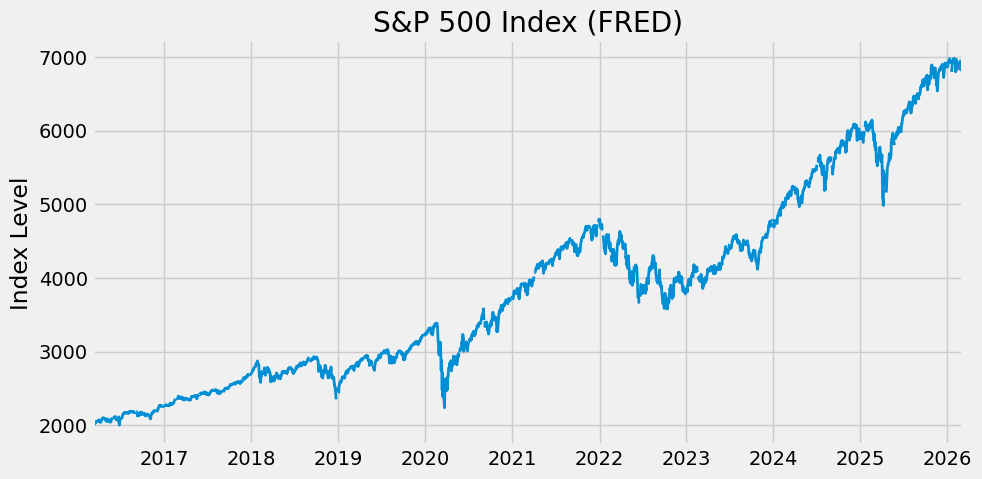

In [230]:
plt.figure(figsize=(10,5))

sp500.plot(lw=2)

plt.title("S&P 500 Index (FRED)")
plt.ylabel("Index Level")

plt.grid(True)

plt.show()

### Key Insights

* The S&P 500 shows a clear long-term upward trend from 2017 to 2026, meaning the U.S. stock market has grown strongly over time.

* There is a sharp drop in early 2020 when the COVID-19 pandemic caused panic in financial markets.

* After the crash, the market recovered very quickly as governments and central banks supported the economy.

* The market becomes more volatile around 2022 when interest rates start rising.

* Despite these short-term shocks, the stock market continues reaching new highs over the long run.

### Searching for GDP indicators

In [231]:
gdp_search = fred.search("GDP" , order_by='popularity')
gdp_search.head(5)

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
GDP,GDP,2026-03-08,2026-03-08,Gross Domestic Product,1947-01-01,2025-10-01,Quarterly,Q,Billions of Dollars,Bil. of $,Seasonally Adjusted Annual Rate,SAAR,2026-02-20 07:47:50-06:00,95,BEA Account Code: A191RC Gross domestic produ...
GDPC1,GDPC1,2026-03-08,2026-03-08,Real Gross Domestic Product,1947-01-01,2025-10-01,Quarterly,Q,Billions of Chained 2017 Dollars,Bil. of Chn. 2017 $,Seasonally Adjusted Annual Rate,SAAR,2026-02-20 07:48:22-06:00,95,BEA Account Code: A191RX Real gross domestic ...
PAYEMS,PAYEMS,2026-03-08,2026-03-08,"All Employees, Total Nonfarm",1939-01-01,2026-02-01,Monthly,M,Thousands of Persons,Thous. of Persons,Seasonally Adjusted,SA,2026-03-06 08:13:02-06:00,88,"All Employees: Total Nonfarm, commonly known a..."
GFDEGDQ188S,GFDEGDQ188S,2026-03-08,2026-03-08,Federal Debt: Total Public Debt as Percent of ...,1966-01-01,2025-10-01,Quarterly,Q,Percent of GDP,% of GDP,Seasonally Adjusted,SA,2026-03-03 17:51:29-06:00,87,Federal Debt: Total Public Debt as Percent of ...
A939RX0Q048SBEA,A939RX0Q048SBEA,2026-03-08,2026-03-08,Real gross domestic product per capita,1947-01-01,2025-10-01,Quarterly,Q,Chained 2017 Dollars,Chn. 2017 $,Seasonally Adjusted Annual Rate,SAAR,2026-02-20 07:54:53-06:00,81,BEA Account Code: A939RX For more information...


In [232]:
gdp = fred.get_series("GDP")
real_gdp = fred.get_series("GDPC1")
gdp_growth = fred.get_series("A191RL1Q225SBEA")

In [233]:
macro_df = pd.DataFrame({
    "GDP": gdp,
    "Real GDP": real_gdp,
    "GDP Growth": gdp_growth
})
macro_df = macro_df.dropna()
macro_df = macro_df.loc[START_DATE:END_DATE]
macro_df.head()

,GDP,Real GDP,GDP Growth
2017-01-01,19280.08,19398.34,2.00
2017-04-01,19438.64,19506.95,2.30
2017-07-01,19692.60,19660.77,3.20
2017-10-01,20037.09,19882.35,4.60
2018-01-01,20328.55,20044.08,3.30


## Plotting Macroeconomic Indicators

### GDP Plot

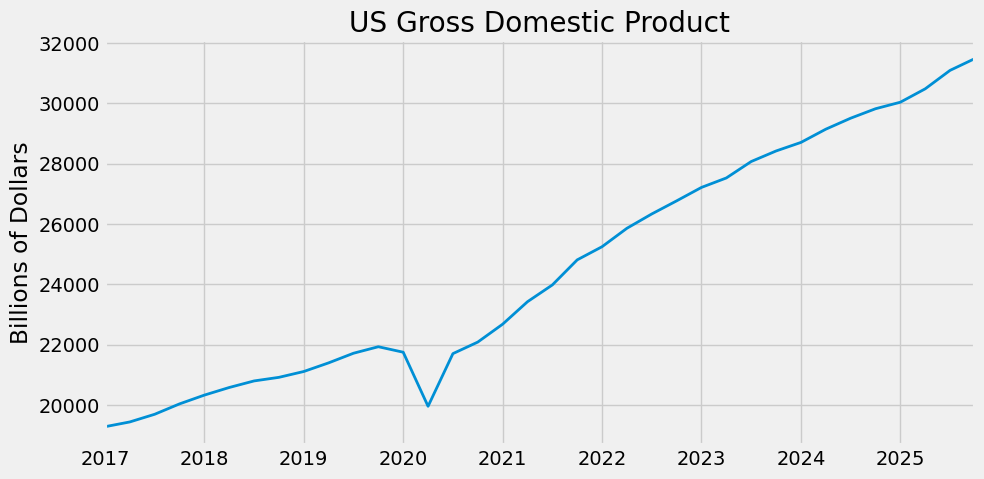

In [234]:
plt.figure(figsize=(10,5))
macro_df["GDP"].plot(lw=2)

plt.title("US Gross Domestic Product")
plt.ylabel("Billions of Dollars")

plt.show()

### Key Insights

* U.S. GDP increases steadily over time, showing that the economy has been growing overall.

* In 2020 there is a sudden drop because economic activity slowed during the COVID-19 pandemic.

* After this decline, GDP rebounds quickly as businesses reopen and economic activity picks up again.

* From 2021 onward, GDP continues growing consistently.

* By 2025–2026, GDP reaches its highest levels, showing the strong recovery of the economy.

### Real GDP Vs Nominal GDP

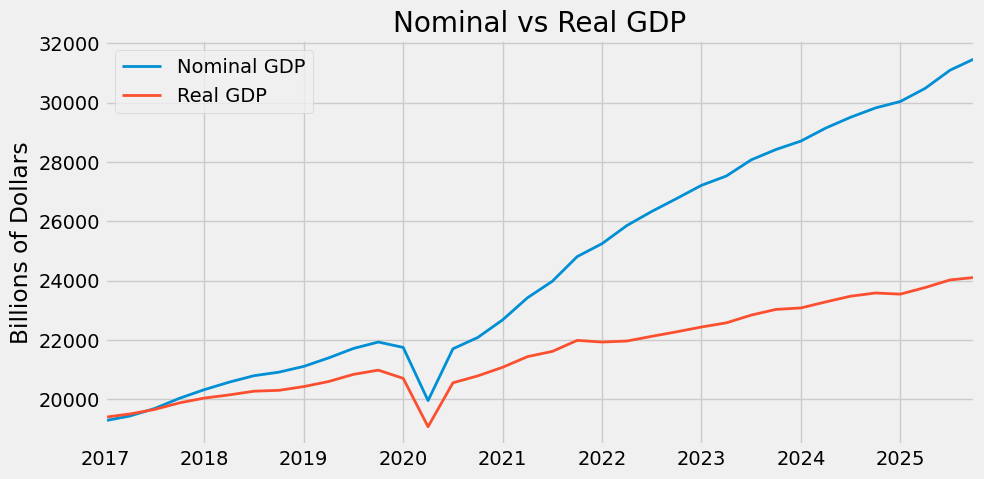

In [235]:
plt.figure(figsize=(10,5))

macro_df["GDP"].plot(label="Nominal GDP" , lw=2)
macro_df["Real GDP"].plot(label="Real GDP" , lw=2)

plt.title("Nominal vs Real GDP")
plt.ylabel("Billions of Dollars")

plt.legend()

plt.show()

### Key Insights

* Nominal GDP grows significantly faster than Real GDP, indicating that inflation contributes substantially to overall economic growth in the United States.

* Both GDP measures experience a sharp decline in 2020, reflecting the economic contraction caused by the COVID-19 pandemic.

* After 2020, Nominal GDP rises much more steeply than Real GDP, suggesting that inflation played a major role in economic expansion during the recovery period.

* The widening gap between Nominal and Real GDP after 2021 indicates periods of elevated inflation in the economy.

* Real GDP shows steadier and more moderate growth, representing the actual increase in economic output after adjusting for inflation.

### GDP Growth Rate

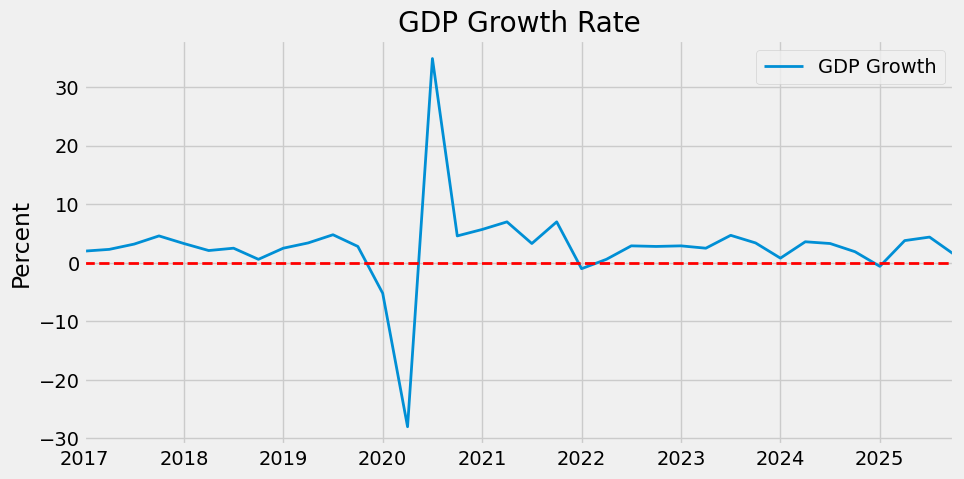

In [236]:
plt.figure(figsize=(10,5))

macro_df["GDP Growth"].plot(lw=2)

plt.axhline(0 , color="red", linestyle="--", linewidth=2)
plt.title("GDP Growth Rate")
plt.ylabel("Percent")

plt.legend()
plt.show()

### Key Insights

* The GDP Growth Rate in the United States generally stays between 2–5%, indicating stable economic expansion during most periods.

* A dramatic economic contraction occurs in early 2020, when GDP growth drops sharply below zero due to the COVID-19 pandemic.

* The sharp rebound immediately afterward shows an exceptionally high positive growth spike, reflecting rapid economic recovery once lockdowns and restrictions were lifted.

* After the recovery phase, growth stabilizes again within the normal expansion range, suggesting the economy returned to a steady growth path.

* Occasional dips near 0% growth indicate short periods of economic slowdown but not full recessi* 

### Searching for Unemployment Rate

In [237]:
unemployment_search = fred.search("unemployment" , order_by="popularity")
unemployment_search.head(5)

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
UNRATE,UNRATE,2026-03-08,2026-03-08,Unemployment Rate,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:12:35-06:00,99,The unemployment rate represents the number of...
CPIAUCSL,CPIAUCSL,2026-03-08,2026-03-08,Consumer Price Index for All Urban Consumers: ...,1947-01-01,2026-01-01,Monthly,M,Index 1982-1984=100,Index 1982-1984=100,Seasonally Adjusted,SA,2026-02-13 08:05:50-06:00,98,The Consumer Price Index for All Urban Consume...
PAYEMS,PAYEMS,2026-03-08,2026-03-08,"All Employees, Total Nonfarm",1939-01-01,2026-02-01,Monthly,M,Thousands of Persons,Thous. of Persons,Seasonally Adjusted,SA,2026-03-06 08:13:02-06:00,88,"All Employees: Total Nonfarm, commonly known a..."
SAHMREALTIME,SAHMREALTIME,2026-03-08,2026-03-08,Real-time Sahm Rule Recession Indicator,1959-12-01,2026-02-01,Monthly,M,Percentage Points,Percentage Points,Seasonally Adjusted,SA,2026-03-06 08:24:28-06:00,87,Sahm Recession Indicator signals the start of ...
ICSA,ICSA,2026-03-08,2026-03-08,Initial Claims,1967-01-07,2026-02-28,"Weekly, Ending Saturday",W,Number,Number,Seasonally Adjusted,SA,2026-03-05 07:48:33-06:00,83,An initial claim is a claim filed by an unempl...


### Unemployment Rate Plot

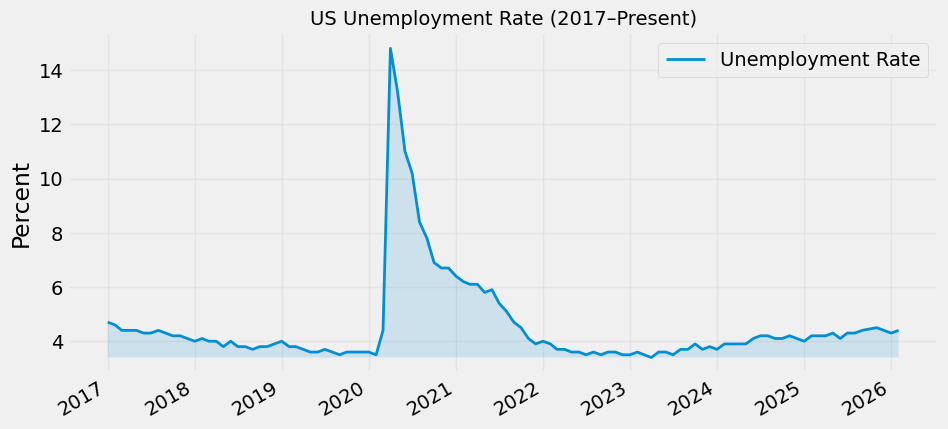

In [238]:
unemployment = fred.get_series("UNRATE").loc[START_DATE:END_DATE]
unemployment = unemployment.dropna()

plt.figure(figsize=(10,5))
unemployment.plot(
    lw=2,
    label="Unemployment Rate")

plt.title("US Unemployment Rate (2017–Present)", fontsize=14)
plt.ylabel("Percent")

plt.fill_between(
    unemployment.index,
    unemployment,
    unemployment.min(),
    alpha=0.15)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

### Key Insights

* The Unemployment Rate in the United States remained relatively low between 2017–2019, indicating a strong labor market before major economic disruptions.

* A dramatic spike in unemployment occurs in 2020, reaching nearly 15%, caused by widespread job losses during the COVID-19 pandemic.

* The unemployment rate declines rapidly after the spike, reflecting fast labor market recovery as businesses reopened and economic activity resumed.

* By 2022–2023, unemployment falls back to around 3.5–4%, signaling a return to a tight labor market.

* A slight upward trend appears after 2024, suggesting mild labor market cooling while still remaining within historically healthy levels.

### Consumer Price Index (Inflation) Rate Plot

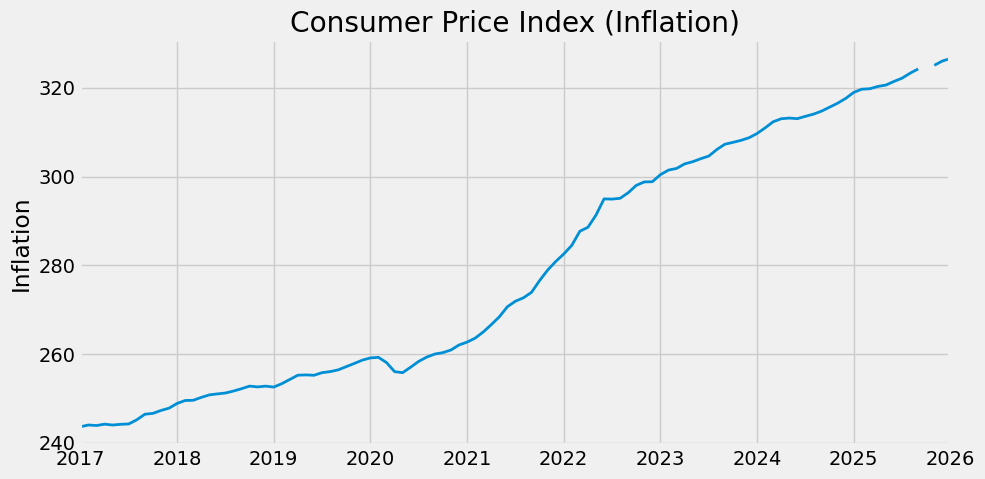

In [239]:
cpi = fred.get_series("CPIAUCSL").loc[START_DATE:END_DATE]

plt.figure(figsize=(10,5))
cpi.plot(lw=2)

plt.title("Consumer Price Index (Inflation)")
plt.ylabel("Inflation")
plt.show()

### Key Insights

* The Consumer Price Index steadily increases over time, which reflects the normal rise in prices in the economy.

* There is a small slowdown around 2020 when economic activity dropped during the pandemic.

* Inflation rises much faster between 2021 and 2022 as demand recovers and supply problems occur.

* After 2023 the rate of increase becomes slower, suggesting inflation starts stabilizing.

* Overall, the chart shows how prices gradually rise over time with periods of faster inflation.

### Interest Rate Issued By The Federal Reserve Over the Years

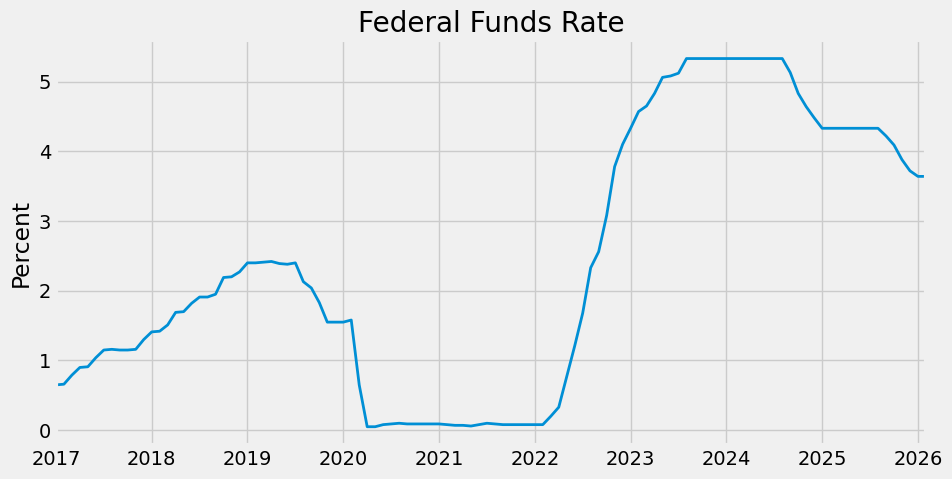

In [240]:
fed_rate = fred.get_series("FEDFUNDS").loc[START_DATE:END_DATE]

plt.figure(figsize=(10,5))
fed_rate.plot(lw=2)

plt.title("Federal Funds Rate")
plt.ylabel("Percent")

plt.show()

### Key Insights

* Interest rates rise gradually between 2017 and 2019 as the economy grows.

* In 2020 the Federal Reserve cuts rates close to zero to support the economy during the pandemic.

* These very low rates remain in place for some time to help economic recovery.

* Starting in 2022, interest rates increase quickly as the Federal Reserve tries to control high inflation.

* After peaking around 2023–2024, the rate begins to decline slightly.

### Yield Curve Spread (Recession Indicator) --> (When it goes below 0 --> Recession Warning) 

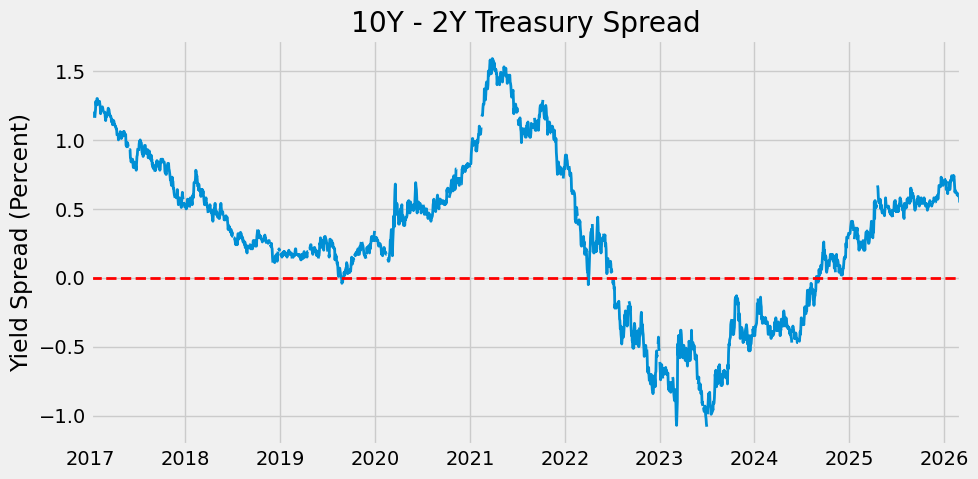

In [241]:
spread = fred.get_series("T10Y2Y").loc[START_DATE:END_DATE]

plt.figure(figsize=(10,5))
spread.plot(lw=2)

plt.axhline(0, color="red", linestyle="--", linewidth=2)

plt.title("10Y - 2Y Treasury Spread")
plt.ylabel("Yield Spread (Percent)")

plt.show()

### Key Insights

* The difference between the 10-year and 2-year Treasury yields is often used to understand economic expectations.

* When the spread becomes negative, it means short-term interest rates are higher than long-term rates.

* This situation appears between 2022 and 2024 and is often seen as a warning sign of economic slowdown.

* The inversion becomes deepest around 2023 when interest rates are rising quickly.

* Later the spread turns positive again, suggesting improving economic expectations.

### Recession Visualization

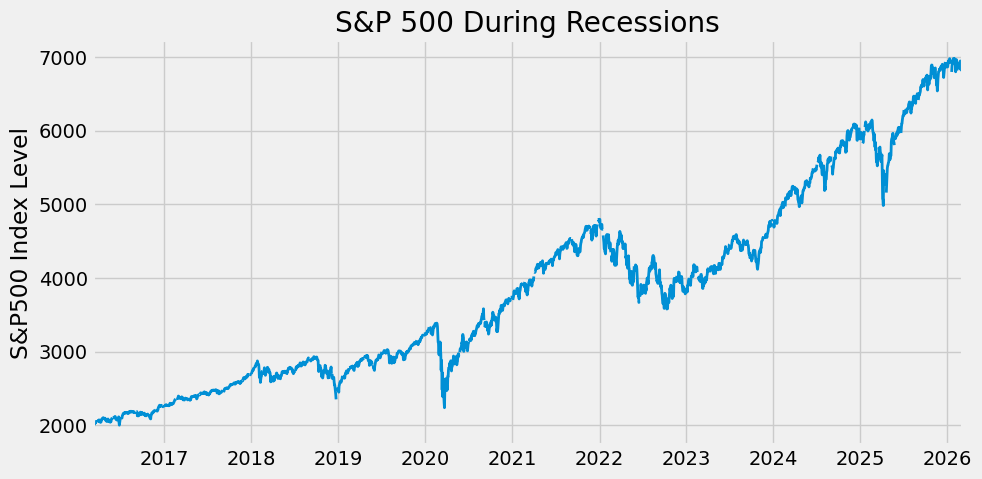

In [242]:
recession = fred.get_series("USREC").loc[START_DATE:END_DATE]

plt.figure(figsize=(10,5))

sp500.plot(label="S&P 500" , lw = 2)

plt.title("S&P 500 During Recessions")
plt.ylabel("S&P500 Index Level")

plt.show()

### Key Insights

* The stock market generally grows over the long term even though there are temporary declines.

* In 2020 the market falls sharply during the pandemic recession.

* After the drop, the market recovers quickly as economic support measures are introduced.

* The chart shows that recessions can cause short-term market declines.

* However, the long-term trend of the stock market still remains upward.

### Unemployment vs Recessions

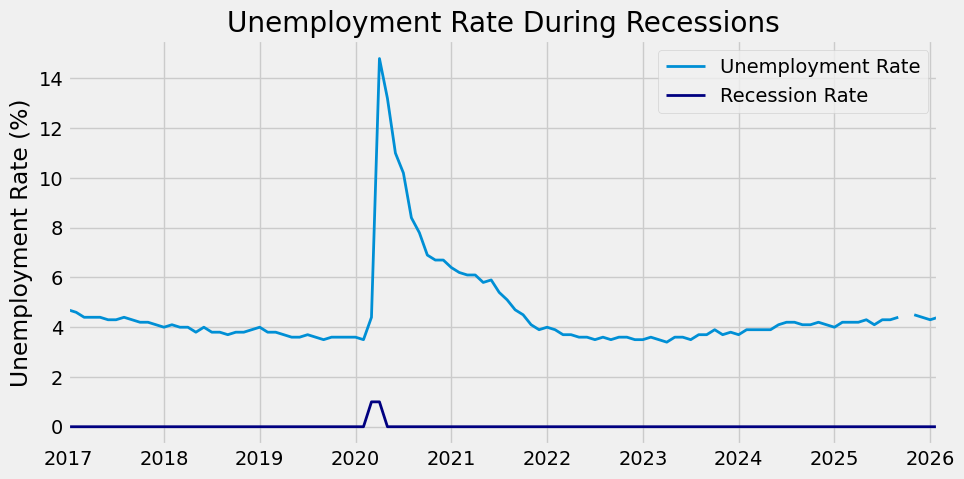

In [243]:
unemployment = fred.get_series("UNRATE").loc[START_DATE:END_DATE]
recession = fred.get_series("USREC").loc[START_DATE:END_DATE]

plt.figure(figsize=(10,5))

unemployment.plot(label="Unemployment Rate" , lw=2)
recession.plot(label="Recession Rate" , color = "navy" , lw=2)

plt.title("Unemployment Rate During Recessions")
plt.ylabel("Unemployment Rate (%)")

plt.legend()

plt.show()

### Key Insights

* Unemployment usually stays low when the economy is doing well.

* During the 2020 recession, unemployment rises very sharply.

* This increase happens because businesses reduce hiring or lay off workers during economic downturns.

* After the recession ends, unemployment gradually declines as jobs return.

* This pattern shows that unemployment rises during recessions and falls during economic recovery.

### Federal Interest Rate vs Stock Market

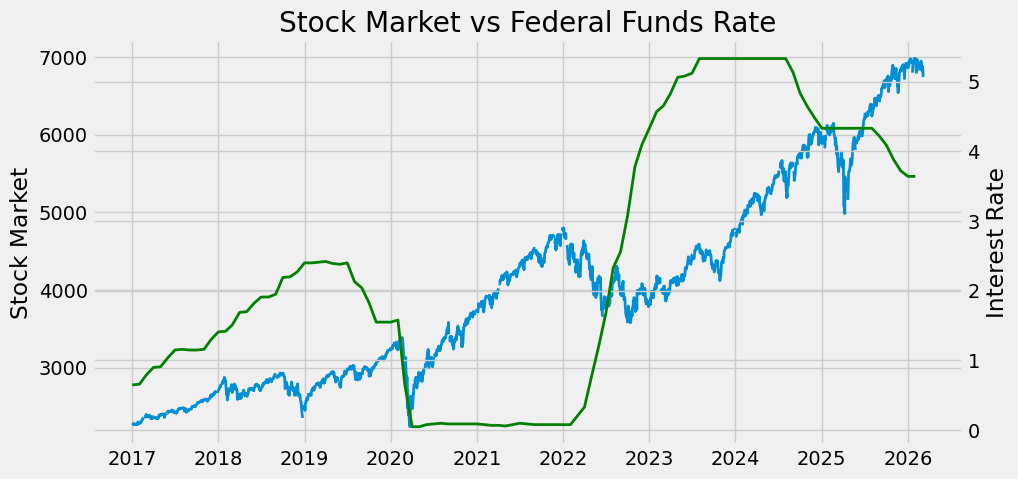

In [244]:
fed_rate = fred.get_series("FEDFUNDS").loc[START_DATE:END_DATE]
sp500 = fred.get_series("SP500").loc[START_DATE:END_DATE]

fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(sp500, label="S&P 500", lw=2)
ax1.set_ylabel("Stock Market")

ax2 = ax1.twinx()

ax2.plot(fed_rate, label="Fed Funds Rate" , color = "green" ,  lw=2)
ax2.set_ylabel("Interest Rate")

plt.title("Stock Market vs Federal Funds Rate")

plt.show()

### Key Insights

* The stock market and interest rates often move in opposite directions.

* In 2020 interest rates were cut to near zero to support the economy, which helped the stock market recover.

* When interest rates started rising in 2022, the stock market became more volatile.

* Higher interest rates can make borrowing more expensive for businesses and investors.

* Even with higher rates, the stock market eventually continued its long-term growth trend.

### GDP Growth Cycles

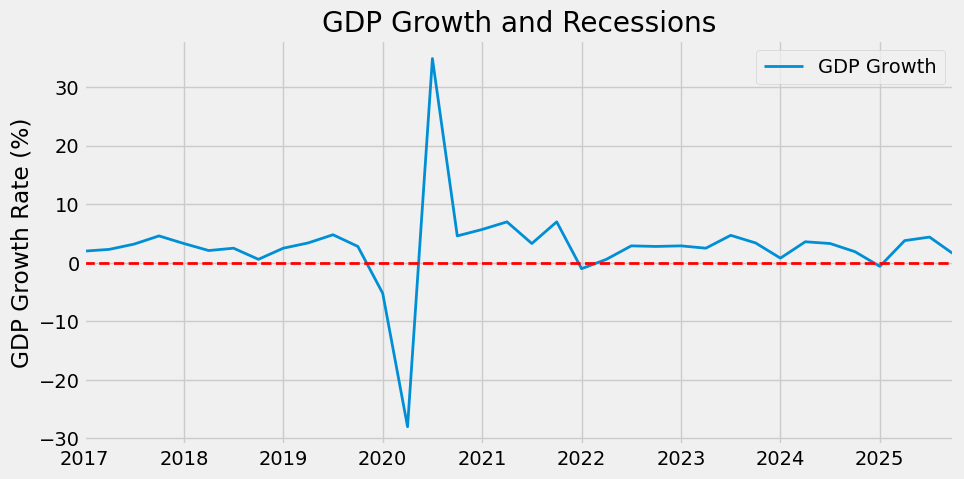

In [245]:
gdp_growth = fred.get_series("A191RL1Q225SBEA").loc[START_DATE:END_DATE]
recession = fred.get_series("USREC").loc[START_DATE:END_DATE]

plt.figure(figsize=(10,5))

gdp_growth.plot(label="GDP Growth" , lw=2)

plt.axhline(0 , color="red", linestyle="--", linewidth=2)

plt.title("GDP Growth and Recessions")
plt.ylabel("GDP Growth Rate (%)")

plt.legend()

plt.show()

### Key Insights

* GDP growth is usually positive during normal economic periods.

* In 2020 the economy experiences a large contraction due to the pandemic recession.

* This decline is followed by a strong rebound as the economy reopens.

* After the recovery, growth stabilizes at more typical levels.

* The chart clearly shows how the economy moves through cycles of slowdown and recovery

### Final Observations

* The charts show that the U.S. economy experienced a major disruption in 2020 during the COVID-19 pandemic, which caused a sharp drop in GDP growth, a spike in unemployment, and a crash in the stock market.

* To support the economy, the Federal Reserve lowered interest rates close to zero, which helped financial markets recover quickly.

* As the economy reopened, GDP growth rebounded strongly and unemployment gradually fell back to normal levels.

* During 2021–2022, inflation increased significantly, which can be seen in the rise of the Consumer Price Index.

* To control inflation, the Federal Reserve began raising interest rates aggressively starting in 2022.

* Higher interest rates led to more volatility in financial markets and also caused the yield curve to invert, which is often seen as a warning sign for possible economic slowdown.

* Despite these shocks, the data shows that the U.S. economy and stock market recovered and continued their long-term growth trend.